In [1]:
import numpy as np
import matplotlib.pyplot as plt

from Triangle.Constants import * 
from Triangle.GW import * 
from Triangle.FFTTools import *
from Triangle.Noise import *
from Triangle.Orbit import *
from Triangle.TDI import *

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


no cupy 


In [2]:
wave_data = np.loadtxt("/Users/taijidatacenter/Downloads/hphc.txt")
wave_data.shape 

(2, 2392002)

In [3]:
dt  = 15. 
Tobs = len(wave_data[0]) * dt 
t_data = np.arange(len(wave_data[0])) * dt 
Tobs / YEAR 

1.1369497346592485

In [4]:
waveform_generator = General_Injection(
    t_data=t_data, 
    hp_data=wave_data[0],
    hc_data=wave_data[1],
)


In [5]:
orbit = Orbit(
    OrbitDir="/Users/taijidatacenter/workspace/Triangle-Simulator/OrbitData/TaijiEqualArmOrbit", 
    dt=DAY, 
    pn_order=0, 
)

response_generator = FastMichelsonTDIResponse(
    orbit=orbit, 
    tcb_times=t_data.copy(), 
    use_gpu=False, 
    drop_points=int(1000/dt), 
    interp_method="Spline5", 
)

In [6]:
tdi = response_generator(
    parameters={
        "longitude": 2.232796975919999927e+00, 
        "latitude": 4.989444892403920306e-01, 
    }, 
    waveform_generator=waveform_generator, 
    optimal_combination="True", 
)

tdi.shape 

(3, 2392002)

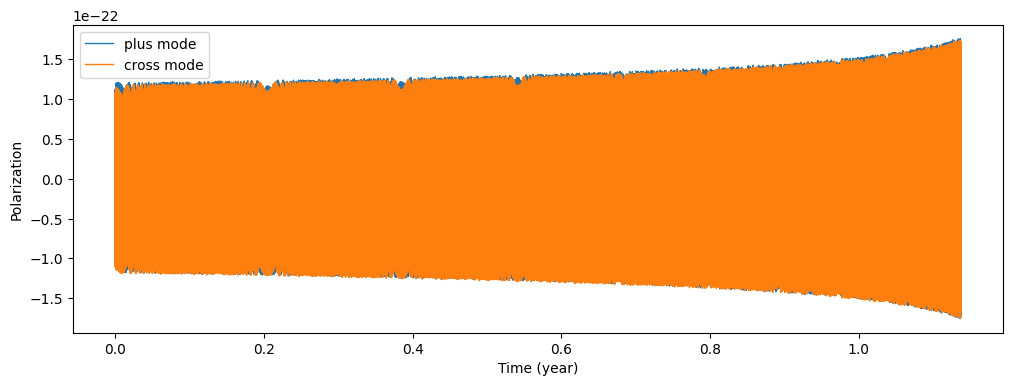

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(t_data/YEAR, wave_data[0], linewidth=1, label="plus mode")
plt.plot(t_data/YEAR, wave_data[1], linewidth=1, label="cross mode")
plt.xlabel("Time (year)")
plt.ylabel("Polarization")
plt.legend(loc="upper left")

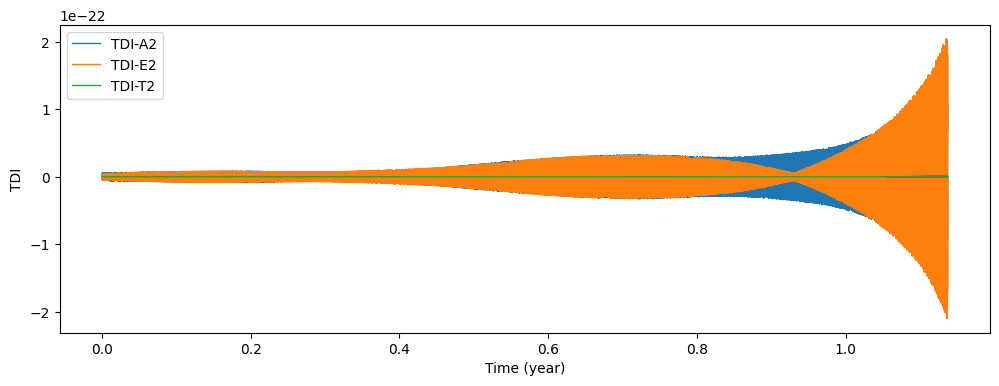

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(t_data/YEAR, tdi[0], linewidth=1, label="TDI-A2")
plt.plot(t_data/YEAR, tdi[1], linewidth=1, label="TDI-E2")
plt.plot(t_data/YEAR, tdi[2], linewidth=1, label="TDI-T2")
plt.xlabel("Time (year)")
plt.ylabel("TDI")
plt.legend(loc="upper left")
# plt.xlim(1.1, 1.145)

Text(0, 0.5, 'Characteristic Strain')

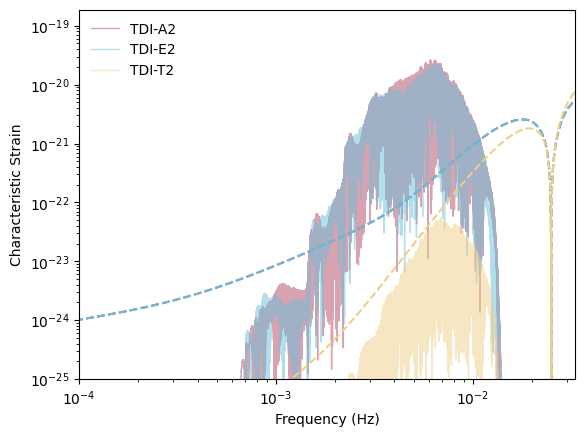

In [9]:
psd_func = TDIPSDs()

ff, xf = FFT_window(
    data_array=tdi[0], 
    fsample=1./dt,
    window_type="tukey",
    window_args_dict=dict(alpha=0.1), 
)
plt.loglog(ff, np.abs(xf) * 2. * ff, linewidth=1, label="TDI-A2", color=RED, alpha=0.5)
plt.loglog(ff, np.sqrt(psd_func.PSD_A2(ff) * ff), linestyle="--", color=RED)

ff, xf = FFT_window(
    data_array=tdi[1], 
    fsample=1./dt,
    window_type="tukey",
    window_args_dict=dict(alpha=0.1), 
)
plt.loglog(ff, np.abs(xf) * 2. * ff, linewidth=1, label="TDI-E2", color=BLUE, alpha=0.5)
plt.loglog(ff, np.sqrt(psd_func.PSD_A2(ff) * ff), linestyle="--", color=BLUE)

ff, xf = FFT_window(
    data_array=tdi[2], 
    fsample=1./dt,
    window_type="tukey",
    window_args_dict=dict(alpha=0.1), 
)
plt.loglog(ff, np.abs(xf) * 2. * ff, linewidth=1, label="TDI-T2", color=YELLOW, alpha=0.5)
plt.loglog(ff, np.sqrt(psd_func.PSD_T2(ff) * ff), linestyle="--", color=YELLOW)

plt.legend(loc="upper left", frameon=False)
plt.xlim(1e-4, 0.033)
plt.ylim(1e-25,)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Characteristic Strain")

In [10]:
np.savetxt(
    fname="/Users/taijidatacenter/Downloads/0108TDI.txt", 
    X=np.array([t_data, tdi[0], tdi[1]]).T,
    header="Time (s) | TDI-A2 | TDI-E2"
)